## EDA and preprocessing

import all required libraries   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/raw/heart.csv")
# df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.shape

(1025, 14)

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
# --- Remove duplicate rows ---
df.columns = df.columns.str.strip()
df_clean = df.drop_duplicates().reset_index(drop=True)

# Check columns
print(df_clean.columns.tolist())

# --- If you want to reset the index after dropping ---
df = df_clean.reset_index(drop=True)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
df_clean.shape

(302, 14)

In [7]:
df_clean.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [8]:
print(df_clean.describe())

             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.526027   22.903527    0.4

Basic database information

In [9]:
print(df_clean.info())
print(df_clean.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB
None
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca   

### Investigating the `target` label convention

Before treating `target == 1` as "disease present," check what the clinical markers actually look like in each group. If the labelling convention matches the standard UCI one, group `1` should show the *worse* profile (older, lower max heart rate, higher ST depression, more major vessels affected).

In [10]:
df_clean.groupby("target")[["age", "thalach", "oldpeak", "exang", "ca"]].mean()

,age,thalach,oldpeak,exang,ca
target,,,,,
0,56.601449,139.101449,1.585507,0.550725,1.166667
1,52.585366,158.378049,0.586585,0.140244,0.341463


**Finding:** `target == 0` has the worse profile (older, lower `thalach`, higher `oldpeak`, more `exang`, more `ca`) — the opposite of the usual assumption. In this release of the dataset, `target == 1` actually means **no disease** and `target == 0` means **disease present**.

We relabel so `target == 1` consistently means "disease present" for the rest of this project (training, evaluation, and the serving API all assume this convention).

In [11]:
# Relabel: target=1 -> disease present, target=0 -> no disease
df_clean["target"] = 1 - df_clean["target"]
df = df_clean.copy()
df_clean["target"].value_counts()

target
0    164
1    138
Name: count, dtype: int64

<Axes: xlabel='target'>

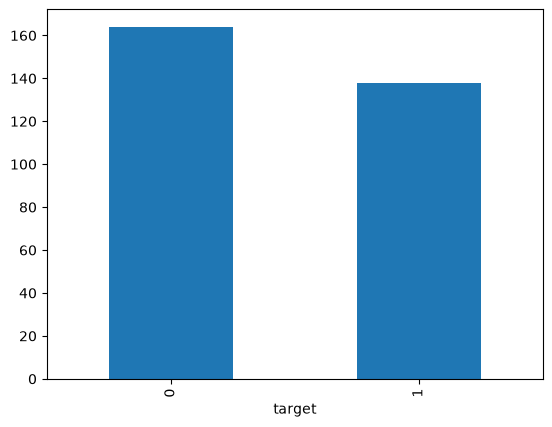

In [12]:
df_clean['target'].value_counts().plot(kind='bar')

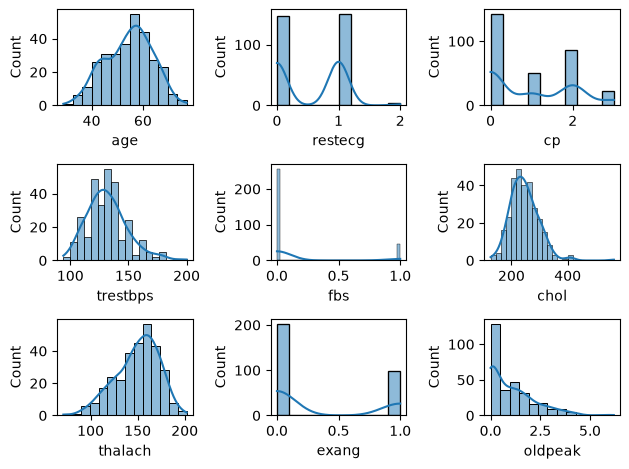

In [13]:
def plotting(var,num):
    plt.subplot(3,3,num)
    sns.histplot(df[var],kde = True)

plotting('age',1)
plotting('restecg',2)
plotting('cp',3)
plotting('trestbps',4)
plotting('fbs',5)
plotting('chol', 6)
plotting('thalach',7)
plotting('exang',8)
plotting('oldpeak',9)


plt.tight_layout()    

<Axes: xlabel='age', ylabel='Count'>

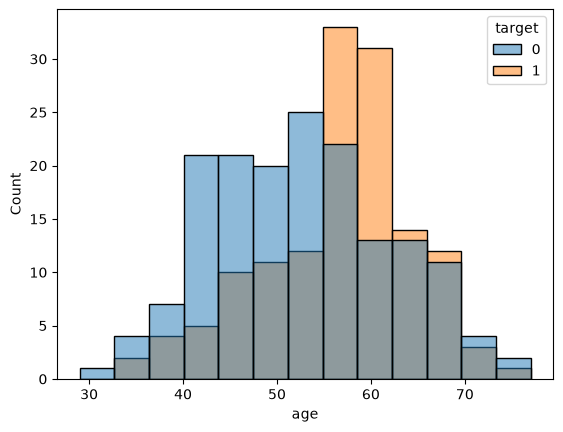

In [14]:
sns.histplot(df_clean, x="age", hue="target")

<Axes: xlabel='restecg', ylabel='Count'>

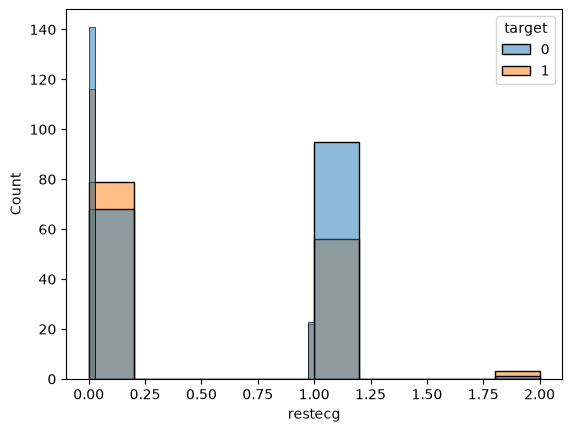

In [15]:
sns.histplot(df_clean, x="restecg", hue="target") 
sns.histplot(df_clean, x="fbs", hue="target") 
# drop the fbs, restecg

### Separate features and target

In [16]:
from sklearn.model_selection import train_test_split

x = df_clean.drop("target", axis=1)
y = df_clean["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y, test_size=0.2)

### Identify categorical and numeric features

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

categorical_features = [
    "cp", "restecg", "slope", "ca", "thal"
]

binary_features = [
    "sex", "fbs", "exang"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features),
        ("binary", "passthrough", binary_features)
    ]
)

#### Fit and transform

In [18]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
print(x_train_processed.shape)
print(x_test_processed.shape)

(241, 27)
(61, 27)


In [19]:
df_encoded = pd.get_dummies(df)
df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,1
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,1
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,1
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,1


### Save cleaned dataframe


In [20]:
df_clean.to_csv('../data/processed/heart_clean.csv', index=False)

In [21]:
import joblib # to save 
import os

# Create the directory if it doesn't exist
os.makedirs("../data/processed/", exist_ok=True)

In [22]:
pd.DataFrame(x_train_processed).to_csv("../data/processed/x_train_processed.csv", index=False)
pd.DataFrame(x_test_processed).to_csv("../data/processed/x_test_processed.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)


joblib.dump(preprocessor, "../data/processed/preprocessor.joblib")

print("✓ All datasets saved!")

✓ All datasets saved!
